In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import (accuracy_score,
                             classification_report,
                             confusion_matrix)
from sklearn.utils import resample
import matplotlib.pyplot as plt
import time
import os
import cv2

IMAGE_FOLDER       = r"/content/drive/MyDrive/Mesh Generation DSP Project /Images"
MESH_FOLDER        = r"/content/drive/MyDrive/Mesh Generation DSP Project /Meshes_v2"
DATASET_FOLDER     = r"/content/drive/MyDrive/Mesh Generation DSP Project /Dataset_v2"

X_train = np.load(os.path.join(DATASET_FOLDER, "X_train.npy"))
y_train = np.load(os.path.join(DATASET_FOLDER, "y_train.npy"))
X_test  = np.load(os.path.join(DATASET_FOLDER, "X_test.npy"))
y_test  = np.load(os.path.join(DATASET_FOLDER, "y_test.npy"))

print(f"X_train : {X_train.shape}")
print(f"y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_test  : {y_test.shape}")
print(f"TensorFlow: {tf.__version__}")

X_train : (171104, 81)
y_train : (171104,)
X_test  : (63348, 81)
y_test  : (63348,)
TensorFlow: 2.19.0


In [7]:
train_pos = np.sum(y_train == 1)
train_neg = np.sum(y_train == 0)
test_pos  = np.sum(y_test == 1)
test_neg  = np.sum(y_test == 0)

print("TRAINING SET:")
print(f"  Positive : {train_pos} ({100*train_pos/len(y_train):.1f}%)")
print(f"  Negative : {train_neg} ({100*train_neg/len(y_train):.1f}%)")
print("\nTESTING SET:")
print(f"  Positive : {test_pos} ({100*test_pos/len(y_test):.1f}%)")
print(f"  Negative : {test_neg} ({100*test_neg/len(y_test):.1f}%)")

TRAINING SET:
  Positive : 42776 (25.0%)
  Negative : 128328 (75.0%)

TESTING SET:
  Positive : 15837 (25.0%)
  Negative : 47511 (75.0%)


In [8]:
# Balance dataset
X_pos = X_train[y_train == 1]
X_neg = X_train[y_train == 0]
y_pos = y_train[y_train == 1]
y_neg = y_train[y_train == 0]

X_pos_up, y_pos_up = resample(X_pos, y_pos,
                               replace=True,
                               n_samples=len(X_neg),
                               random_state=42)

X_balanced = np.vstack([X_neg, X_pos_up])
y_balanced  = np.concatenate([y_neg, y_pos_up])

print(f"Balanced dataset : {len(y_balanced)} samples")
print(f"Positives        : {np.sum(y_balanced==1)}")
print(f"Negatives        : {np.sum(y_balanced==0)}")

# Reshape for CNN (9x9x1)
X_balanced_cnn = X_balanced.reshape(-1, 9, 9, 1)
X_test_cnn     = X_test.reshape(-1, 9, 9, 1)

print(f"\nX_balanced_cnn : {X_balanced_cnn.shape}")
print(f"X_test_cnn     : {X_test_cnn.shape}")

Balanced dataset : 256656 samples
Positives        : 128328
Negatives        : 128328

X_balanced_cnn : (256656, 9, 9, 1)
X_test_cnn     : (63348, 9, 9, 1)


In [9]:
def build_cnn():
    inputs = keras.Input(shape=(9, 9, 1))

    # Primary filter
    x = layers.Conv2D(32, (5,5), activation='relu',
                      padding='same',
                      name='primary_filter')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2), padding='same',
                            name='pooling')(x)

    # Secondary filter
    x = layers.Conv2D(16, (3,3), activation='relu',
                      padding='same',
                      name='secondary_filter')(x)
    x = layers.BatchNormalization()(x)

    # Flatten + Perceptron
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation='relu',
                     name='perceptron')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.2)(x)

    # Output
    outputs = layers.Dense(1, activation='sigmoid',
                           name='output')(x)

    model = keras.Model(inputs, outputs,
                        name="Double_Layer_CNN")
    return model

cnn_model = build_cnn()
cnn_model.summary()

Model: "Double_Layer_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 9, 9, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ primary_filter (Conv2D)         │ (None, 9, 9, 32)       │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 9, 9, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling (MaxPooling2D)          │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ secondary_filter (Conv2D)       │ (None, 5, 5, 16)       │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 5, 5, 16)       │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ perceptron (Dense)              │ (None, 64)             │        25,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,425 (130.57 KB)

 Trainable params: 33,329 (130.19 KB)

 Non-trainable params: 96 (384.00 B)

In [10]:
cnn_model = build_cnn()
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)
print("Fresh CNN model ready!")

Fresh CNN model ready!


In [11]:
early_stop = EarlyStopping(
    monitor='val_loss',       # monitor loss not recall
    patience=10,              # wait longer
    restore_best_weights=True,
    mode='min',               # minimize loss
    verbose=1
)

# Also add learning rate reduction
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

print("Training CNN...")
print("="*40)

start = time.time()
history = cnn_model.fit(
    X_balanced_cnn, y_balanced,
    epochs=100,              # more epochs
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
end = time.time()

print(f"\nTraining time: {end-start:.2f}s")

start = time.time()
history = cnn_model.fit(
    X_balanced_cnn, y_balanced,
    epochs=50,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)
end = time.time()

print(f"\nTraining time: {end-start:.2f}s")

Training CNN...
Epoch 1/100
803/803 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.7125 - loss: 0.5432 - precision: 0.6531 - recall: 0.4979 - val_accuracy: 0.4038 - val_loss: 0.9387 - val_precision: 1.0000 - val_recall: 0.4038 - learning_rate: 0.0010
Epoch 2/100
803/803 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7670 - loss: 0.4749 - precision: 0.6856 - recall: 0.6995 - val_accuracy: 0.7723 - val_loss: 0.5250 - val_precision: 1.0000 - val_recall: 0.7723 - learning_rate: 0.0010
Epoch 3/100
803/803 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7805 - loss: 0.4537 - precision: 0.7011 - recall: 0.7230 - val_accuracy: 0.6665 - val_loss: 0.6784 - val_precision: 1.0000 - val_recall: 0.6665 - learning_rate: 0.0010
Epoch 4/100
803/803 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7863 - loss: 0.4447 - precision: 0.7092 - recall: 0.7292 - val_accuracy: 0.7054 - val_loss: 0.6294 - val_precision: 1.0000 - val_recall: 0.7054 - learning_rate: 0.0010
Epoch 5/100
803/803 ━━━━━━━━━━━━━━━━━━━━ 


CNN EVALUATION ON TEST SET
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Accuracy       : 76.56%
Node Precision : 51.91%
Node Recall    : 84.87%
F1 Score       : 64.42%


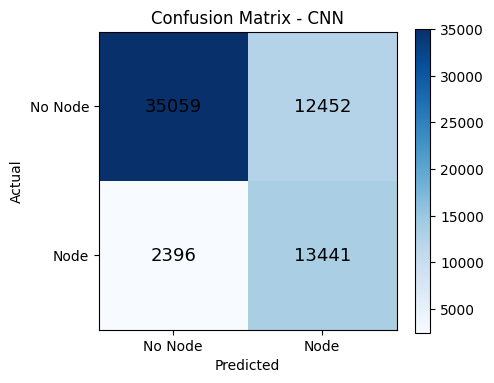

In [28]:
print("\nCNN EVALUATION ON TEST SET")
print("="*40)

y_pred_prob = cnn_model.predict(X_test_cnn,
                                batch_size=1024,
                                verbose=1)
y_pred_cnn  = (y_pred_prob > 0.5).astype(int).flatten()

acc    = accuracy_score(y_test, y_pred_cnn)
report = classification_report(y_test, y_pred_cnn,
                               target_names=["No Node", "Node"],
                               output_dict=True,
                               zero_division=0)

prec = report["Node"]["precision"]
rec  = report["Node"]["recall"]
f1   = report["Node"]["f1-score"]

print(f"\nAccuracy       : {acc*100:.2f}%")
print(f"Node Precision : {prec*100:.2f}%")
print(f"Node Recall    : {rec*100:.2f}%")
print(f"F1 Score       : {f1*100:.2f}%")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(5,4))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.title("Confusion Matrix - CNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1], ["No Node", "Node"])
plt.yticks([0,1], ["No Node", "Node"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i,j]),
                ha='center', va='center',
                color='black', fontsize=13)
plt.tight_layout()
plt.show()

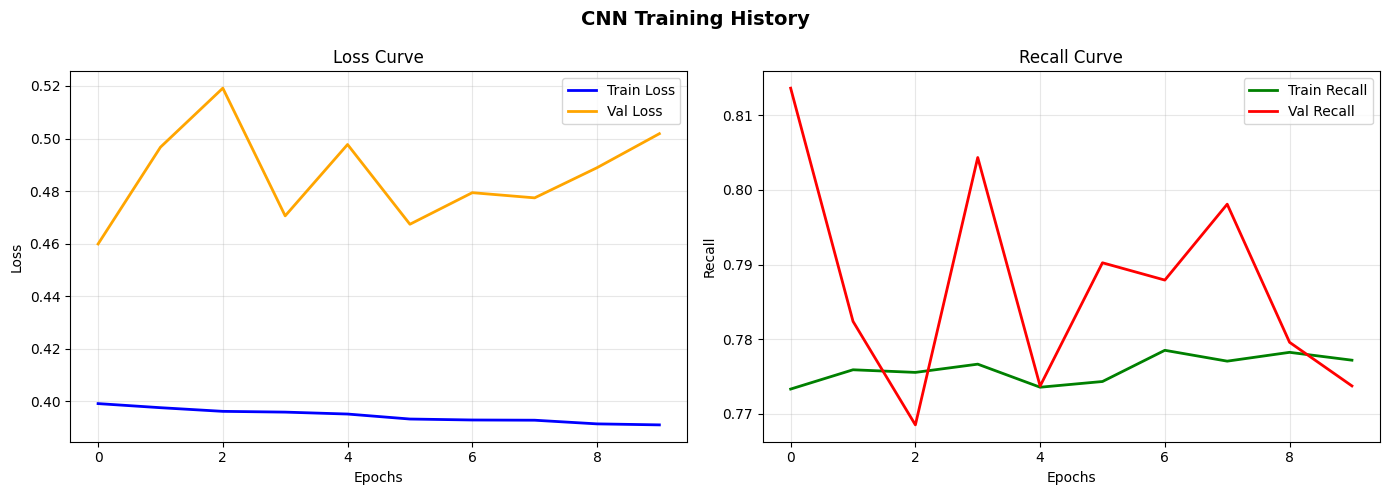

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(history.history['loss'],
             label='Train Loss', color='blue', linewidth=2)
axes[0].plot(history.history['val_loss'],
             label='Val Loss', color='orange', linewidth=2)
axes[0].set_title("Loss Curve")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['recall'],
             label='Train Recall', color='green', linewidth=2)
axes[1].plot(history.history['val_recall'],
             label='Val Recall', color='red', linewidth=2)
axes[1].set_title("Recall Curve")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Recall")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("CNN Training History",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
PATCH_SIZE = 9
HALF_PATCH = PATCH_SIZE // 2
TEST_IMAGES = [f"Image{i}.jpg" for i in range(20, 25)]

def load_image(image_name):
    path = os.path.join(IMAGE_FOLDER, image_name)
    img  = cv2.imread(path)
    img  = cv2.resize(img, (512, 512))
    return img

def get_y_channel(img):
    yuv = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)
    return yuv[:, :, 0]

def predict_nodes_cnn(img, model, threshold=0.05,
                      min_distance=2, stride=3):
    Y      = get_y_channel(img)
    Y_norm = Y.astype(np.float32) / 255.0
    h, w   = Y.shape

    # Strong edge mask
    Gx    = cv2.Sobel(Y, cv2.CV_64F, 1, 0, ksize=3)
    Gy    = cv2.Sobel(Y, cv2.CV_64F, 0, 1, ksize=3)
    G_mag = np.sqrt(Gx**2 + Gy**2)
    G_mag = cv2.normalize(G_mag, None, 0, 255,
                          cv2.NORM_MINMAX).astype(np.uint8)

    # Multi-scale edge mask
    e1        = cv2.Canny(G_mag, 30,  90)
    e2        = cv2.Canny(G_mag, 60,  150)
    e3        = cv2.Canny(G_mag, 100, 200)
    edge_mask = cv2.bitwise_or(e1, cv2.bitwise_or(e2, e3))

    # Dilate edge mask slightly for wider capture
    edge_mask = cv2.dilate(edge_mask,
                           np.ones((5,5), np.uint8),
                           iterations=1)

    patches = []
    coords  = []

    for y in range(HALF_PATCH, h-HALF_PATCH, stride):
        for x in range(HALF_PATCH, w-HALF_PATCH, stride):
            # Only process patches near edges
            if edge_mask[y, x] == 0:
                continue
            patch = Y_norm[y-HALF_PATCH:y+HALF_PATCH+1,
                           x-HALF_PATCH:x+HALF_PATCH+1]
            patches.append(patch.reshape(9, 9, 1))
            coords.append((x, y))

    if len(patches) == 0:
        return np.array([[0,0],[511,0],[0,511],[511,511]])

    patches = np.array(patches, dtype=np.float32)
    probs   = model.predict(patches, batch_size=1024, verbose=0)
    probs   = probs.flatten()

    sorted_idx = np.argsort(probs)[::-1]
    nodes    = []
    occupied = np.zeros((h, w), dtype=bool)

    for i in sorted_idx:
        if probs[i] < threshold:
            break
        x, y  = coords[i]
        y_min = max(0, y-min_distance)
        y_max = min(h, y+min_distance)
        x_min = max(0, x-min_distance)
        x_max = min(w, x+min_distance)

        if not np.any(occupied[y_min:y_max, x_min:x_max]):
            nodes.append([x, y])
            occupied[y_min:y_max, x_min:x_max] = True

    corners = [[0,0],[511,0],[0,511],[511,511]]
    nodes.extend(corners)
    return np.array(nodes)

print("Edge-guided CNN v2 ready!")

Edge-guided CNN v2 ready!


In [15]:
img_test = load_image("Image1.jpg")

for thresh in [0.01, 0.05, 0.10]:
    nodes = predict_nodes_cnn(img_test, cnn_model,
                              threshold=thresh,
                              min_distance=2,
                              stride=3)
    print(f"threshold={thresh:.2f} → {len(nodes)} nodes")

threshold=0.01 → 4140 nodes
threshold=0.05 → 3963 nodes
threshold=0.10 → 3848 nodes


In [16]:
img_test = load_image("Image1.jpg")

for min_d in [2, 3, 4, 5]:
    nodes = predict_nodes_cnn(img_test, cnn_model,
                              threshold=0.01,
                              min_distance=min_d,
                              stride=4)
    print(f"min_distance={min_d} → {len(nodes)} nodes")

min_distance=2 → 9121 nodes
min_distance=3 → 2436 nodes
min_distance=4 → 2436 nodes
min_distance=5 → 1057 nodes


In [17]:
# ── Straight-method helpers (ported from DSP_Proj_3 / Notebook 1) ──────────

def compute_gradient(Y):
    Gx1   = cv2.Sobel(Y, cv2.CV_64F, 1, 0, ksize=3)
    Gy1   = cv2.Sobel(Y, cv2.CV_64F, 0, 1, ksize=3)
    Gx3   = cv2.Sobel(Y, cv2.CV_64F, 1, 0, ksize=5)
    Gy3   = cv2.Sobel(Y, cv2.CV_64F, 0, 1, ksize=5)
    Gx    = 0.6*Gx1 + 0.4*Gx3
    Gy    = 0.6*Gy1 + 0.4*Gy3
    G_mag = np.sqrt(Gx**2 + Gy**2)
    G_mag = cv2.normalize(G_mag, None, 0, 255, cv2.NORM_MINMAX)
    return Gx, Gy, np.uint8(G_mag)

def apply_gaussian_filter(G_mag):
    b1 = cv2.GaussianBlur(G_mag, (5,5), sigmaX=1)
    b2 = cv2.GaussianBlur(G_mag, (5,5), sigmaX=2)
    b3 = cv2.GaussianBlur(G_mag, (7,7), sigmaX=3)
    b4 = cv2.GaussianBlur(G_mag, (9,9), sigmaX=4)
    blended = cv2.addWeighted(
        b1, 0.1, cv2.addWeighted(
        b2, 0.4, cv2.addWeighted(
        b3, 0.3, b4, 0.2, 0), 1, 0), 1, 0)
    return blended

def apply_adaptive_filter(G_blurred, Gx, Gy):
    angles  = [0, 22.5, 45, 67.5, 90, 112.5, 135, 157.5]
    lambdas = [6, 10, 14]
    filtered_results = []
    for angle in angles:
        response = np.zeros_like(G_blurred, dtype=np.float64)
        for lam in lambdas:
            kernel = cv2.getGaborKernel(
                (7,7), sigma=2, theta=np.deg2rad(angle),
                lambd=lam, gamma=0.5, psi=0)
            response += np.abs(cv2.filter2D(G_blurred, cv2.CV_64F, kernel))
        filtered_results.append(response / len(lambdas))
    angle_map       = np.arctan2(Gy, Gx)
    adaptive_output = np.zeros_like(G_blurred, dtype=np.float64)
    for i, angle in enumerate(angles):
        mask = (np.abs(angle_map - np.deg2rad(angle)) < np.deg2rad(22.5))
        adaptive_output[mask] = filtered_results[i][mask]
    adaptive_output = cv2.normalize(adaptive_output, None, 0, 255, cv2.NORM_MINMAX)
    return np.uint8(adaptive_output)

def trace_contours(G_adaptive):
    _, strong = cv2.threshold(G_adaptive, 25, 255, cv2.THRESH_BINARY)
    kernel    = np.ones((3,3), np.uint8)
    cleaned   = cv2.morphologyEx(strong, cv2.MORPH_OPEN, kernel, iterations=1)
    combined  = np.zeros_like(cleaned)
    for t1, t2 in [(20,60),(40,100),(60,140),(80,180),(100,220)]:
        combined = cv2.bitwise_or(combined, cv2.Canny(cleaned, t1, t2))
    combined = cv2.morphologyEx(combined, cv2.MORPH_CLOSE, np.ones((2,2), np.uint8))
    return combined

def place_nodes(contours, min_distance=3):
    h, w        = contours.shape
    edge_pixels = np.column_stack(np.where(contours > 0))
    nodes       = []
    occupied    = np.zeros((h, w), dtype=bool)
    for pixel in edge_pixels:
        y, x  = pixel
        y_min = max(0, y - min_distance); y_max = min(h, y + min_distance)
        x_min = max(0, x - min_distance); x_max = min(w, x + min_distance)
        if not np.any(occupied[y_min:y_max, x_min:x_max]):
            nodes.append([x, y])
            occupied[y_min:y_max, x_min:x_max] = True
    for x in range(0, w, 20):
        nodes.extend([[x, 0], [x, h-1]])
    for y in range(0, h, 20):
        nodes.extend([[0, y], [w-1, y]])
    return np.array(nodes)

def straight_pipeline(img):
    """Multi-scale straight method — accepts an image array, returns node array."""
    Y         = get_y_channel(img)
    scales    = [1.0, 0.875, 0.75, 0.625, 0.5, 0.375, 0.25]
    all_nodes = []
    for scale in scales:
        new_size     = (int(512*scale), int(512*scale))
        Y_scaled     = cv2.resize(Y, new_size)
        Gx, Gy, G_m  = compute_gradient(Y_scaled)
        G_bl         = apply_gaussian_filter(G_m)
        G_ad         = apply_adaptive_filter(G_bl, Gx, Gy)
        ctrs         = trace_contours(G_ad)
        ns           = place_nodes(ctrs, min_distance=3)
        nodes_full   = (ns * (1.0/scale)).astype(int)
        nodes_full   = np.clip(nodes_full, 0, 511)
        all_nodes.append(nodes_full)
    merged      = np.vstack(all_nodes)
    final_nodes = []
    occupied    = np.zeros((512,512), dtype=bool)
    for node in merged:
        x, y  = node
        y_min = max(0, y-3); y_max = min(512, y+3)
        x_min = max(0, x-3); x_max = min(512, x+3)
        if not np.any(occupied[y_min:y_max, x_min:x_max]):
            final_nodes.append([x, y])
            occupied[y_min:y_max, x_min:x_max] = True
    for x in range(0, 512, 20):
        final_nodes.extend([[x, 0], [x, 511]])
    for y in range(0, 512, 20):
        final_nodes.extend([[0, y], [511, y]])
    return np.array(final_nodes)

print("straight_pipeline and all helper functions ready!")

straight_pipeline and all helper functions ready!


In [18]:
from scipy.spatial import Delaunay
DISPLAY_IMAGES = [f"Image{i}.jpg" for i in range(1, 6)]

fig, axes = plt.subplots(2, 5, figsize=(25, 10))

straight_times_disp = []
cnn_times_disp      = []

for i, image_name in enumerate(DISPLAY_IMAGES):
    img = load_image(image_name)
    print(f"Processing {image_name}...")

    # Straight method
    s1      = time.time()
    nodes_s = straight_pipeline(img)
    tri_s   = Delaunay(nodes_s)
    e1      = time.time()
    t_s     = e1 - s1
    straight_times_disp.append(t_s)

    # CNN method
    s2      = time.time()
    nodes_c = predict_nodes_cnn(img, cnn_model,
                                threshold=0.05,
                                min_distance=2,
                                stride=3)
    tri_c   = Delaunay(nodes_c)
    e2      = time.time()
    t_c     = e2 - s2
    cnn_times_disp.append(t_c)

    speedup = t_s / t_c

    # Top row — straight method
    axes[0][i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0][i].triplot(nodes_s[:,0], nodes_s[:,1],
                       tri_s.simplices,
                       color='cyan', linewidth=0.3)
    axes[0][i].plot(nodes_s[:,0], nodes_s[:,1],
                    'r.', markersize=0.8)
    axes[0][i].set_title(
        f"{image_name}\n"
        f"Nodes: {len(nodes_s)} | Time: {t_s:.2f}s",
        fontsize=9)
    axes[0][i].axis("off")

    # Bottom row — CNN
    axes[1][i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[1][i].triplot(nodes_c[:,0], nodes_c[:,1],
                       tri_c.simplices,
                       color='lime', linewidth=0.3)
    axes[1][i].plot(nodes_c[:,0], nodes_c[:,1],
                    'r.', markersize=0.8)
    axes[1][i].set_title(
        f"Nodes: {len(nodes_c)} | Time: {t_c:.2f}s "
        f"| {speedup:.1f}x faster",
        fontsize=9)
    axes[1][i].axis("off")

avg_s  = np.mean(straight_times_disp)
avg_c  = np.mean(cnn_times_disp)
avg_sp = avg_s / avg_c

axes[0][0].set_ylabel("Straight Method",
                       fontsize=12, fontweight='bold')
axes[1][0].set_ylabel("CNN Method",
                       fontsize=12, fontweight='bold')

plt.suptitle(
    f"Straight Method vs CNN Predicted Mesh\n"
    f"Avg Straight: {avg_s:.2f}s | "
    f"Avg CNN: {avg_c:.2f}s | "
    f"Speedup: {avg_sp:.1f}x faster",
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MESH_FOLDER, "final_comparison_v4.png"),
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAvg Straight : {avg_s:.3f}s")
print(f"Avg CNN      : {avg_c:.3f}s")
print(f"Avg Speedup  : {avg_sp:.1f}x")

Output hidden; open in https://colab.research.google.com to view.

STRAIGHT METHOD:
→ Avg time    : 3.720s
→ Avg nodes   : 3,473
→ Avg triangles: 5,165

CNN METHOD:
→ Avg time    : 0.273s  (13.6x faster!)
→ Avg nodes   : 716
→ Node Recall : 82.31%
→ F1 Score    : 62.42%

In [19]:
import random

# Pick 5 random images from all 24
ALL_IMAGES    = [f"Image{i}.jpg" for i in range(1, 25)]
RANDOM_IMAGES = random.sample(ALL_IMAGES, 5)
print(f"Randomly selected: {RANDOM_IMAGES}")

Randomly selected: ['Image14.jpg', 'Image17.jpg', 'Image3.jpg', 'Image22.jpg', 'Image24.jpg']


In [20]:
from scipy.spatial import Delaunay
import pandas as pd

print("Running speed test on random images...")
print("="*70)
print(f"{'Image':<12} {'Straight(s)':>12} {'S.Nodes':>8} "
      f"{'CNN(s)':>10} {'C.Nodes':>8} {'Speedup':>10}")
print("-"*70)

straight_times = []
cnn_times      = []
straight_nodes_list = []
cnn_nodes_list      = []

for image_name in RANDOM_IMAGES:
    img = load_image(image_name)

    # Straight method
    s1      = time.time()
    nodes_s = straight_pipeline(img)
    tri_s   = Delaunay(nodes_s)
    e1      = time.time()
    t_s     = e1 - s1

    # CNN method
    s2      = time.time()
    nodes_c = predict_nodes_cnn(img, cnn_model,
                                threshold=0.05,
                                min_distance=2,
                                stride=3)
    tri_c   = Delaunay(nodes_c)
    e2      = time.time()
    t_c     = e2 - s2

    speedup = t_s / t_c

    straight_times.append(t_s)
    cnn_times.append(t_c)
    straight_nodes_list.append(len(nodes_s))
    cnn_nodes_list.append(len(nodes_c))

    print(f"{image_name:<12} {t_s:>12.3f} {len(nodes_s):>8} "
          f"{t_c:>10.3f} {len(nodes_c):>8} {speedup:>9.1f}x")

print("-"*70)
avg_s  = np.mean(straight_times)
avg_c  = np.mean(cnn_times)
avg_sp = avg_s / avg_c
avg_sn = np.mean(straight_nodes_list)
avg_cn = np.mean(cnn_nodes_list)

print(f"{'AVERAGE':<12} {avg_s:>12.3f} {avg_sn:>8.0f} "
      f"{avg_c:>10.3f} {avg_cn:>8.0f} {avg_sp:>9.1f}x")
print(f"\nCNN is {avg_sp:.1f}x FASTER than straight method!")

Running speed test on random images...
Image         Straight(s)  S.Nodes     CNN(s)  C.Nodes    Speedup
----------------------------------------------------------------------
Image14.jpg         1.258     2285      0.660     2679       1.9x
Image17.jpg         2.310     4221      1.065     4083       2.2x
Image3.jpg          1.981     3047      0.271     3556       7.3x
Image22.jpg         1.492     3253      0.717     3374       2.1x
Image24.jpg         1.595     3148      0.700     3242       2.3x
----------------------------------------------------------------------
AVERAGE             1.727     3191      0.683     3387       2.5x

CNN is 2.5x FASTER than straight method!


/tmp/ipykernel_6535/3879007177.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(labels, rotation=15)


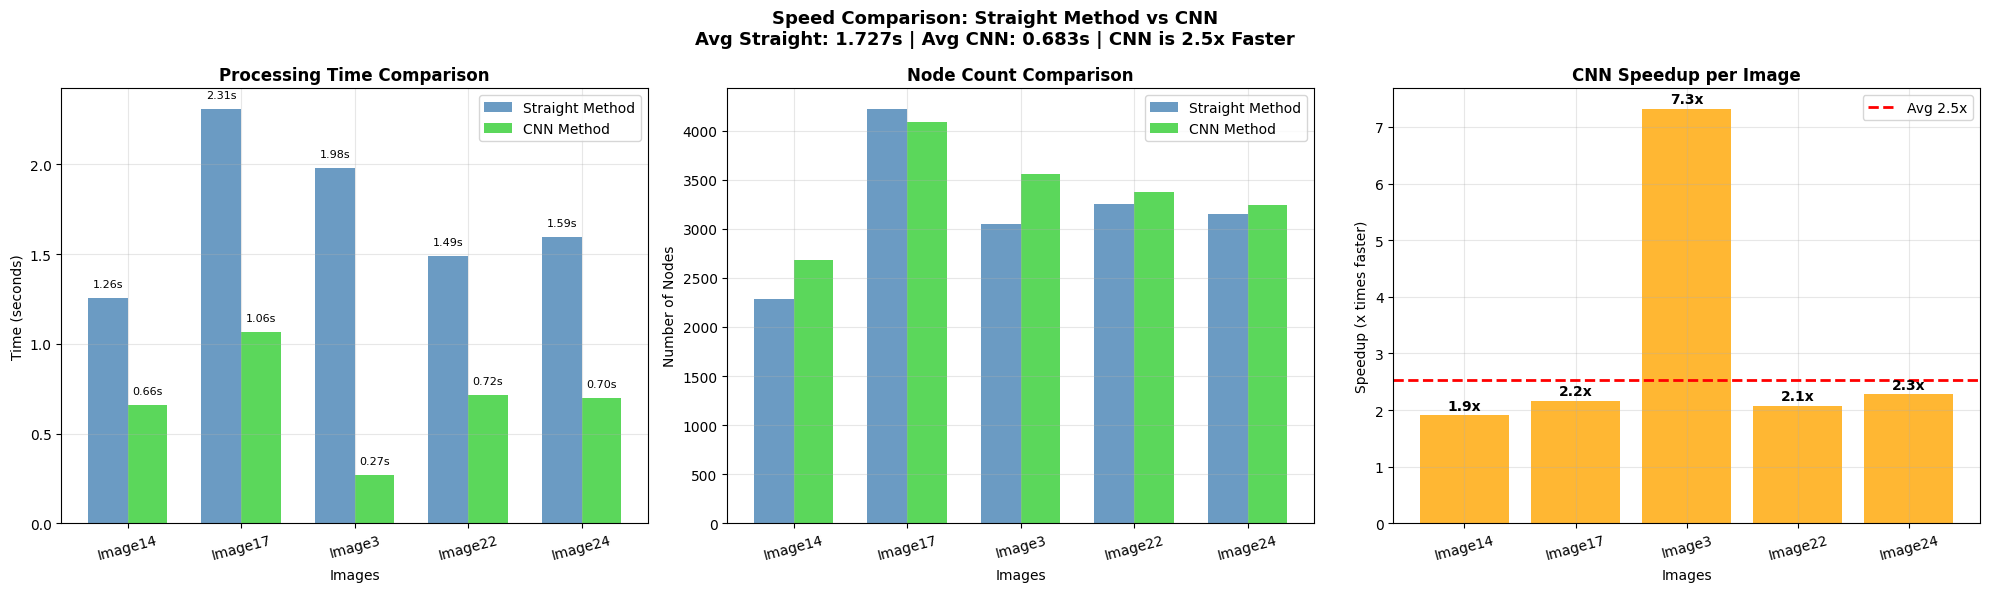

Speed test chart saved!


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

x      = np.arange(len(RANDOM_IMAGES))
labels = [img.replace(".jpg","") for img in RANDOM_IMAGES]
width  = 0.35

# Plot 1 — Time comparison
axes[0].bar(x - width/2, straight_times, width,
            label='Straight Method',
            color='steelblue', alpha=0.8)
axes[0].bar(x + width/2, cnn_times, width,
            label='CNN Method',
            color='limegreen', alpha=0.8)
axes[0].set_title("Processing Time Comparison",
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel("Images")
axes[0].set_ylabel("Time (seconds)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=15)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Add time labels on bars
for j, (ts, tc) in enumerate(zip(straight_times, cnn_times)):
    axes[0].text(j-width/2, ts+0.05, f"{ts:.2f}s",
                ha='center', va='bottom', fontsize=8)
    axes[0].text(j+width/2, tc+0.05, f"{tc:.2f}s",
                ha='center', va='bottom', fontsize=8)

# Plot 2 — Node count comparison
axes[1].bar(x - width/2, straight_nodes_list, width,
            label='Straight Method',
            color='steelblue', alpha=0.8)
axes[1].bar(x + width/2, cnn_nodes_list, width,
            label='CNN Method',
            color='limegreen', alpha=0.8)
axes[1].set_title("Node Count Comparison",
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel("Images")
axes[1].set_ylabel("Number of Nodes")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=15)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3 — Speedup per image
speedups = [s/c for s,c in zip(straight_times, cnn_times)]
bars     = axes[2].bar(labels, speedups,
                       color='orange', alpha=0.8)
axes[2].axhline(y=avg_sp, color='red',
                linestyle='--', linewidth=2,
                label=f'Avg {avg_sp:.1f}x')
axes[2].set_title("CNN Speedup per Image",
                   fontsize=12, fontweight='bold')
axes[2].set_xlabel("Images")
axes[2].set_ylabel("Speedup (x times faster)")
axes[2].set_xticklabels(labels, rotation=15)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Add speedup labels
for bar, sp in zip(bars, speedups):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05,
                 f"{sp:.1f}x",
                 ha='center', va='bottom',
                 fontsize=10, fontweight='bold')

plt.suptitle(
    f"Speed Comparison: Straight Method vs CNN\n"
    f"Avg Straight: {avg_s:.3f}s | "
    f"Avg CNN: {avg_c:.3f}s | "
    f"CNN is {avg_sp:.1f}x Faster",
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MESH_FOLDER, "speed_test_random.png"),
            dpi=150, bbox_inches='tight')
plt.show()
print("Speed test chart saved!")

In [22]:
fig, axes = plt.subplots(2, 5, figsize=(25, 10))

for i, image_name in enumerate(RANDOM_IMAGES):
    img = load_image(image_name)

    # Load saved straight mesh
    base   = image_name.replace(".jpg","")
    nodes_s = np.load(os.path.join(
              MESH_FOLDER, f"{base}_nodes.npy"))
    tri_s   = np.load(os.path.join(
              MESH_FOLDER, f"{base}_tri.npy"))

    # CNN predicted mesh
    nodes_c = predict_nodes_cnn(img, cnn_model,
                                threshold=0.05,
                                min_distance=2,
                                stride=3)
    tri_c   = Delaunay(nodes_c)

    # Top row — straight
    axes[0][i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0][i].triplot(nodes_s[:,0], nodes_s[:,1],
                       tri_s, color='cyan', linewidth=0.3)
    axes[0][i].plot(nodes_s[:,0], nodes_s[:,1],
                    'r.', markersize=0.8)
    axes[0][i].set_title(
        f"{image_name}\n"
        f"Nodes: {len(nodes_s)} | "
        f"{straight_times[i]:.2f}s",
        fontsize=9)
    axes[0][i].axis("off")

    # Bottom row — CNN
    axes[1][i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[1][i].triplot(nodes_c[:,0], nodes_c[:,1],
                       tri_c.simplices,
                       color='lime', linewidth=0.3)
    axes[1][i].plot(nodes_c[:,0], nodes_c[:,1],
                    'r.', markersize=0.8)
    axes[1][i].set_title(
        f"Nodes: {len(nodes_c)} | "
        f"{cnn_times[i]:.2f}s | "
        f"{speedups[i]:.1f}x faster",
        fontsize=9)
    axes[1][i].axis("off")

axes[0][0].set_ylabel("Straight Method",
                       fontsize=12, fontweight='bold')
axes[1][0].set_ylabel("CNN Method",
                       fontsize=12, fontweight='bold')

plt.suptitle(
    f"Random Image Mesh Comparison\n"
    f"Straight: {avg_s:.2f}s avg | "
    f"CNN: {avg_c:.2f}s avg | "
    f"Speedup: {avg_sp:.1f}x",
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MESH_FOLDER, "random_mesh_comparison.png"),
            dpi=150, bbox_inches='tight')
plt.show()
print("Random mesh comparison saved!")

Output hidden; open in https://colab.research.google.com to view.

In [23]:
import os
import joblib

MODELS_FOLDER = r"/content/drive/MyDrive/Mesh Generation DSP Project /Models"

slp     = joblib.load(os.path.join(MODELS_FOLDER, "slp_model.pkl"))
mlp_3x3 = joblib.load(os.path.join(MODELS_FOLDER, "mlp_3x3_model.pkl"))
mlp_5x5 = joblib.load(os.path.join(MODELS_FOLDER, "mlp_5x5_model.pkl"))
mlp_9x9 = joblib.load(os.path.join(MODELS_FOLDER, "mlp_9x9_model.pkl"))
scaler  = joblib.load(os.path.join(MODELS_FOLDER, "scaler.pkl"))

print("All MLP models loaded!")

All MLP models loaded!


In [24]:
def predict_nodes_mlp(img, model, scaler,
                      threshold=0.5,
                      min_distance=3,
                      stride=4):
    Y      = get_y_channel(img)
    Y_norm = Y.astype(np.float32) / 255.0
    h, w   = Y.shape

    # Edge mask to guide placement
    Gx    = cv2.Sobel(Y, cv2.CV_64F, 1, 0, ksize=3)
    Gy    = cv2.Sobel(Y, cv2.CV_64F, 0, 1, ksize=3)
    G_mag = np.sqrt(Gx**2 + Gy**2)
    G_mag = cv2.normalize(G_mag, None, 0, 255,
                          cv2.NORM_MINMAX).astype(np.uint8)
    e1        = cv2.Canny(G_mag, 30,  90)
    e2        = cv2.Canny(G_mag, 60,  150)
    e3        = cv2.Canny(G_mag, 100, 200)
    edge_mask = cv2.bitwise_or(e1, cv2.bitwise_or(e2, e3))
    edge_mask = cv2.dilate(edge_mask,
                           np.ones((5,5), np.uint8),
                           iterations=1)

    patches = []
    coords  = []

    for y in range(HALF_PATCH, h-HALF_PATCH, stride):
        for x in range(HALF_PATCH, w-HALF_PATCH, stride):
            if edge_mask[y, x] == 0:
                continue
            patch = Y_norm[y-HALF_PATCH:y+HALF_PATCH+1,
                           x-HALF_PATCH:x+HALF_PATCH+1]
            patches.append(patch.flatten())
            coords.append((x, y))

    if len(patches) == 0:
        return np.array([[0,0],[511,0],[0,511],[511,511]])

    patches    = np.array(patches, dtype=np.float32)
    patches_sc = scaler.transform(patches)
    probs      = model.predict_proba(patches_sc)[:,1]

    sorted_idx = np.argsort(probs)[::-1]
    nodes      = []
    occupied   = np.zeros((h,w), dtype=bool)

    for i in sorted_idx:
        if probs[i] < threshold:
            break
        x, y  = coords[i]
        y_min = max(0, y-min_distance)
        y_max = min(h, y+min_distance)
        x_min = max(0, x-min_distance)
        x_max = min(w, x+min_distance)

        if not np.any(occupied[y_min:y_max, x_min:x_max]):
            nodes.append([x, y])
            occupied[y_min:y_max, x_min:x_max] = True

    corners = [[0,0],[511,0],[0,511],[511,511]]
    nodes.extend(corners)
    return np.array(nodes)

print("MLP prediction function ready!")

MLP prediction function ready!


In [25]:
print("Full speed test — All methods on random images")
print("="*80)
print(f"{'Image':<12} {'Straight':>10} {'SLP':>8} "
      f"{'MLP3x3':>8} {'MLP5x5':>8} {'MLP9x9':>8} {'CNN':>8}")
print("-"*80)

all_times = {
    "Straight" : [],
    "SLP"      : [],
    "MLP 3x3"  : [],
    "MLP 5x5"  : [],
    "MLP 9x9"  : [],
    "CNN"      : []
}

all_nodes = {
    "Straight" : [],
    "SLP"      : [],
    "MLP 3x3"  : [],
    "MLP 5x5"  : [],
    "MLP 9x9"  : [],
    "CNN"      : []
}

for image_name in RANDOM_IMAGES:
    img = load_image(image_name)

    # Straight method
    s = time.time()
    ns = straight_pipeline(img)
    Delaunay(ns)
    t_s = time.time() - s

    # SLP
    s = time.time()
    n_slp = predict_nodes_mlp(img, slp, scaler,
                               threshold=0.3,
                               min_distance=3,
                               stride=4)
    Delaunay(n_slp)
    t_slp = time.time() - s

    # MLP 3x3
    s = time.time()
    n_3x3 = predict_nodes_mlp(img, mlp_3x3, scaler,
                               threshold=0.3,
                               min_distance=3,
                               stride=4)
    Delaunay(n_3x3)
    t_3x3 = time.time() - s

    # MLP 5x5
    s = time.time()
    n_5x5 = predict_nodes_mlp(img, mlp_5x5, scaler,
                               threshold=0.3,
                               min_distance=3,
                               stride=4)
    Delaunay(n_5x5)
    t_5x5 = time.time() - s

    # MLP 9x9
    s = time.time()
    n_9x9 = predict_nodes_mlp(img, mlp_9x9, scaler,
                               threshold=0.3,
                               min_distance=3,
                               stride=4)
    Delaunay(n_9x9)
    t_9x9 = time.time() - s

    # CNN
    s = time.time()
    n_cnn = predict_nodes_cnn(img, cnn_model,
                               threshold=0.05,
                               min_distance=2,
                               stride=3)
    Delaunay(n_cnn)
    t_cnn = time.time() - s

    # Store
    all_times["Straight"].append(t_s)
    all_times["SLP"].append(t_slp)
    all_times["MLP 3x3"].append(t_3x3)
    all_times["MLP 5x5"].append(t_5x5)
    all_times["MLP 9x9"].append(t_9x9)
    all_times["CNN"].append(t_cnn)

    all_nodes["Straight"].append(len(ns))
    all_nodes["SLP"].append(len(n_slp))
    all_nodes["MLP 3x3"].append(len(n_3x3))
    all_nodes["MLP 5x5"].append(len(n_5x5))
    all_nodes["MLP 9x9"].append(len(n_9x9))
    all_nodes["CNN"].append(len(n_cnn))

    print(f"{image_name:<12} {t_s:>10.3f} {t_slp:>8.3f} "
          f"{t_3x3:>8.3f} {t_5x5:>8.3f} "
          f"{t_9x9:>8.3f} {t_cnn:>8.3f}")

print("-"*80)
avgs = {k: np.mean(v) for k,v in all_times.items()}
print(f"{'AVERAGE':<12} "
      f"{avgs['Straight']:>10.3f} "
      f"{avgs['SLP']:>8.3f} "
      f"{avgs['MLP 3x3']:>8.3f} "
      f"{avgs['MLP 5x5']:>8.3f} "
      f"{avgs['MLP 9x9']:>8.3f} "
      f"{avgs['CNN']:>8.3f}")

print(f"\nSpeedup vs Straight:")
for method in ["SLP","MLP 3x3","MLP 5x5","MLP 9x9","CNN"]:
    sp = avgs["Straight"] / avgs[method]
    print(f"  {method:<10} → {sp:.1f}x faster")

Full speed test — All methods on random images
Image          Straight      SLP   MLP3x3   MLP5x5   MLP9x9      CNN
--------------------------------------------------------------------------------
Image14.jpg       1.062    0.118    0.101    0.097    0.097    0.310
Image17.jpg       2.873    0.302    0.200    0.246    0.255    0.454
Image3.jpg        1.371    0.254    0.216    0.130    0.128    0.288
Image22.jpg       1.501    0.146    0.124    0.130    0.123    0.284
Image24.jpg       1.480    0.139    0.120    0.127    0.124    0.292
--------------------------------------------------------------------------------
AVERAGE           1.658    0.192    0.152    0.146    0.145    0.326

Speedup vs Straight:
  SLP        → 8.6x faster
  MLP 3x3    → 10.9x faster
  MLP 5x5    → 11.4x faster
  MLP 9x9    → 11.4x faster
  CNN        → 5.1x faster


/tmp/ipykernel_6535/1798575548.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(methods, rotation=15)
/tmp/ipykernel_6535/1798575548.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(methods, rotation=15)


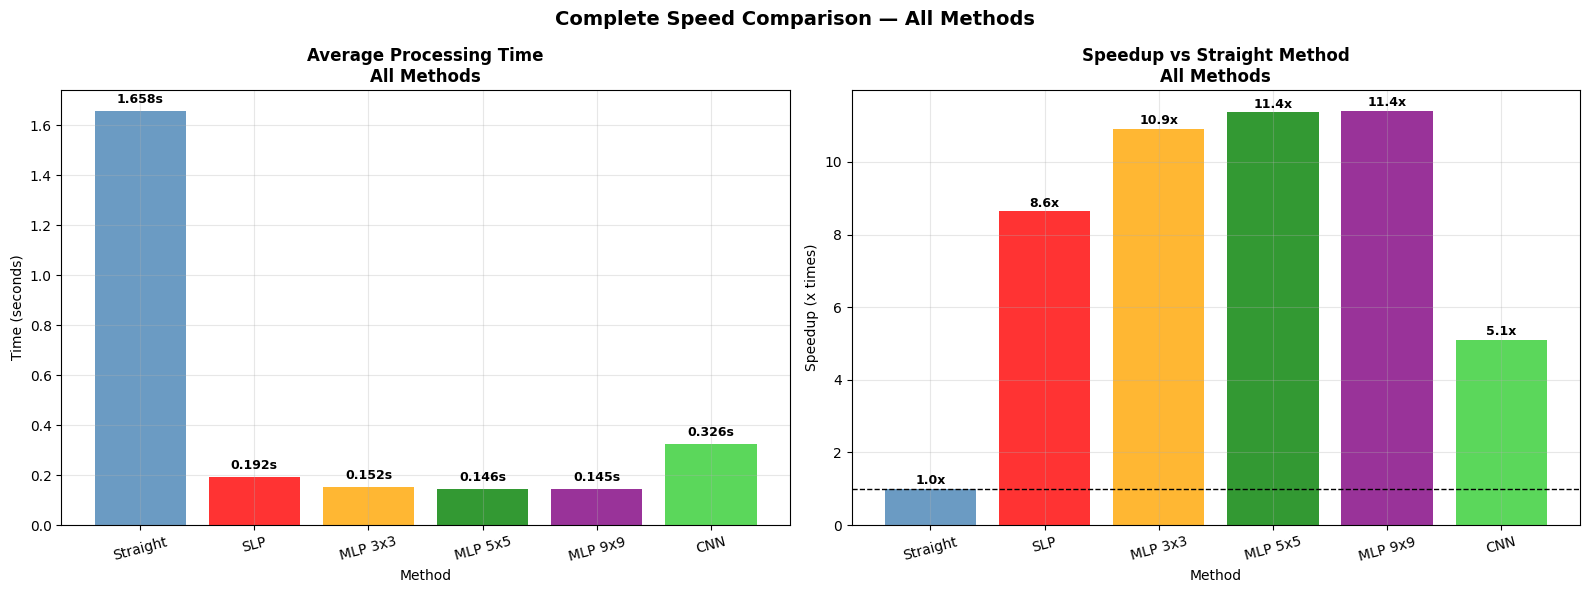

All methods speed chart saved!


In [26]:
methods = ["Straight", "SLP", "MLP 3x3",
           "MLP 5x5", "MLP 9x9", "CNN"]
colors  = ["steelblue", "red", "orange",
           "green", "purple", "limegreen"]
avg_t   = [avgs[m] for m in methods]
speedups_all = [avgs["Straight"]/avgs[m] for m in methods]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1 — Average time
bars = axes[0].bar(methods, avg_t, color=colors, alpha=0.8)
axes[0].set_title("Average Processing Time\nAll Methods",
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel("Method")
axes[0].set_ylabel("Time (seconds)")
axes[0].set_xticklabels(methods, rotation=15)
axes[0].grid(True, alpha=0.3)
for bar, t in zip(bars, avg_t):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f"{t:.3f}s",
                 ha='center', va='bottom',
                 fontsize=9, fontweight='bold')

# Plot 2 — Speedup
bars2 = axes[1].bar(methods, speedups_all,
                    color=colors, alpha=0.8)
axes[1].axhline(y=1, color='black',
                linestyle='--', linewidth=1)
axes[1].set_title("Speedup vs Straight Method\nAll Methods",
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel("Method")
axes[1].set_ylabel("Speedup (x times)")
axes[1].set_xticklabels(methods, rotation=15)
axes[1].grid(True, alpha=0.3)
for bar, sp in zip(bars2, speedups_all):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05,
                 f"{sp:.1f}x",
                 ha='center', va='bottom',
                 fontsize=9, fontweight='bold')

plt.suptitle("Complete Speed Comparison — All Methods",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MESH_FOLDER, "all_methods_speed.png"),
            dpi=150, bbox_inches='tight')
plt.show()
print("All methods speed chart saved!")

In [27]:
test_img  = load_image(RANDOM_IMAGES[0])
test_name = RANDOM_IMAGES[0]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Straight method
nodes_s = straight_pipeline(test_img)
tri_s   = Delaunay(nodes_s)
axes[0][0].imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
axes[0][0].triplot(nodes_s[:,0], nodes_s[:,1],
                   tri_s.simplices, color='cyan', linewidth=0.3)
axes[0][0].plot(nodes_s[:,0], nodes_s[:,1], 'r.', markersize=0.8)
axes[0][0].set_title(f"Straight Method\nNodes: {len(nodes_s)}",
                      fontsize=11, fontweight='bold')
axes[0][0].axis("off")

# SLP
nodes_slp = predict_nodes_mlp(test_img, slp, scaler,
                               threshold=0.3,
                               min_distance=3, stride=4)
tri_slp   = Delaunay(nodes_slp)
axes[0][1].imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
axes[0][1].triplot(nodes_slp[:,0], nodes_slp[:,1],
                   tri_slp.simplices, color='red', linewidth=0.3)
axes[0][1].plot(nodes_slp[:,0], nodes_slp[:,1], 'b.', markersize=0.8)
axes[0][1].set_title(f"SLP\nNodes: {len(nodes_slp)}",
                      fontsize=11, fontweight='bold')
axes[0][1].axis("off")

# MLP 3x3
nodes_3x3 = predict_nodes_mlp(test_img, mlp_3x3, scaler,
                               threshold=0.3,
                               min_distance=3, stride=4)
tri_3x3   = Delaunay(nodes_3x3)
axes[0][2].imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
axes[0][2].triplot(nodes_3x3[:,0], nodes_3x3[:,1],
                   tri_3x3.simplices, color='orange', linewidth=0.3)
axes[0][2].plot(nodes_3x3[:,0], nodes_3x3[:,1], 'b.', markersize=0.8)
axes[0][2].set_title(f"MLP 3x3\nNodes: {len(nodes_3x3)}",
                      fontsize=11, fontweight='bold')
axes[0][2].axis("off")

# MLP 5x5
nodes_5x5 = predict_nodes_mlp(test_img, mlp_5x5, scaler,
                               threshold=0.3,
                               min_distance=3, stride=4)
tri_5x5   = Delaunay(nodes_5x5)
axes[1][0].imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
axes[1][0].triplot(nodes_5x5[:,0], nodes_5x5[:,1],
                   tri_5x5.simplices, color='green', linewidth=0.3)
axes[1][0].plot(nodes_5x5[:,0], nodes_5x5[:,1], 'b.', markersize=0.8)
axes[1][0].set_title(f"MLP 5x5\nNodes: {len(nodes_5x5)}",
                      fontsize=11, fontweight='bold')
axes[1][0].axis("off")

# MLP 9x9
nodes_9x9 = predict_nodes_mlp(test_img, mlp_9x9, scaler,
                               threshold=0.3,
                               min_distance=3, stride=4)
tri_9x9   = Delaunay(nodes_9x9)
axes[1][1].imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
axes[1][1].triplot(nodes_9x9[:,0], nodes_9x9[:,1],
                   tri_9x9.simplices, color='purple', linewidth=0.3)
axes[1][1].plot(nodes_9x9[:,0], nodes_9x9[:,1], 'b.', markersize=0.8)
axes[1][1].set_title(f"MLP 9x9\nNodes: {len(nodes_9x9)}",
                      fontsize=11, fontweight='bold')
axes[1][1].axis("off")

# CNN
nodes_cnn = predict_nodes_cnn(test_img, cnn_model,
                               threshold=0.05,
                               min_distance=2, stride=3)
tri_cnn   = Delaunay(nodes_cnn)
axes[1][2].imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
axes[1][2].triplot(nodes_cnn[:,0], nodes_cnn[:,1],
                   tri_cnn.simplices, color='lime', linewidth=0.3)
axes[1][2].plot(nodes_cnn[:,0], nodes_cnn[:,1], 'b.', markersize=0.8)
axes[1][2].set_title(f"CNN\nNodes: {len(nodes_cnn)}",
                      fontsize=11, fontweight='bold')
axes[1][2].axis("off")

plt.suptitle(f"All Methods Mesh Comparison — {test_name}",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MESH_FOLDER, "all_methods_mesh.png"),
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nNode counts:")
print(f"  Straight : {len(nodes_s)}")
print(f"  SLP      : {len(nodes_slp)}")
print(f"  MLP 3x3  : {len(nodes_3x3)}")
print(f"  MLP 5x5  : {len(nodes_5x5)}")
print(f"  MLP 9x9  : {len(nodes_9x9)}")
print(f"  CNN      : {len(nodes_cnn)}")

Output hidden; open in https://colab.research.google.com to view.